# Лабораториска Вежба 3 — Ненадгледувано Учење
## Mice Protein Expression Dataset

**Цел:** Без употреба на класните ознаки, да се пронајдат кластери во 77-те протеински експресии кои ги сугерираат вистинските класи.

**Методи:** K-Means + DBSCAN

## 1. Импорт на библиотеки

In [1]:
# !pip install ucimlrepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score
from ucimlrepo import fetch_ucirepo

%matplotlib inline

## 2. Вчитување на податоци

In [2]:
dataset = fetch_ucirepo(id=342)

# features and targets in one dataframe
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print('Форма на целиот датасет:', df.shape)
print('Прва колона:', df.columns[0])
print('Последни 4 колони:', list(df.columns[-4:]))

Форма на целиот датасет: (1080, 81)
Прва колона: DYRK1A_N
Последни 4 колони: ['Genotype', 'Treatment', 'Behavior', 'class']


In [3]:
true_labels = df['class'].values
print('Вистински класи:', np.unique(true_labels))
print('Број на класи:', len(np.unique(true_labels)))

X = df.iloc[:, :-4]
print('\nБрој на протеини:', X.shape[1])
print('Прв протеин:', X.columns[0])
print('Последен протеин:', X.columns[-1])

Вистински класи: ['c-CS-m' 'c-CS-s' 'c-SC-m' 'c-SC-s' 't-CS-m' 't-CS-s' 't-SC-m' 't-SC-s']
Број на класи: 8

Број на протеински атрибути: 77
Прв протеин: DYRK1A_N
Последен протеин: CaNA_N


## 3. Претпроцесирање

- **SimpleImputer** — пополнување на missing values со медијана (поробустна од просек)
- **StandardScaler** — нормализација (μ=0, σ=1), задолжително пред кластерирање

In [4]:
print('Missing values пред:', X.isnull().sum().sum())

X = SimpleImputer(strategy='median').fit_transform(X)
X = StandardScaler().fit_transform(X)

print('Форма по претпроцесирање:', X.shape)
print('Средна вредност :', round(X.mean(), 4))
print('Стд. девијација :', round(X.std(), 4))

Missing values пред: 1396
Форма по претпроцесирање: (1080, 77)
Средна вредност (треба ~0): -0.0
Стд. девијација (треба ~1): 1.0


## 4. Визуелизација со PCA

Бидејќи имаме 77 димензии, не можеме директно да ги визуелизираме. PCA ги проецира во 2D за да ја видиме структурата.

Кластерирањето се врши во оригиналниот 77D простор — PCA е само за цртање.

PC1 + PC2 објаснуваат: 42.3% варијанса


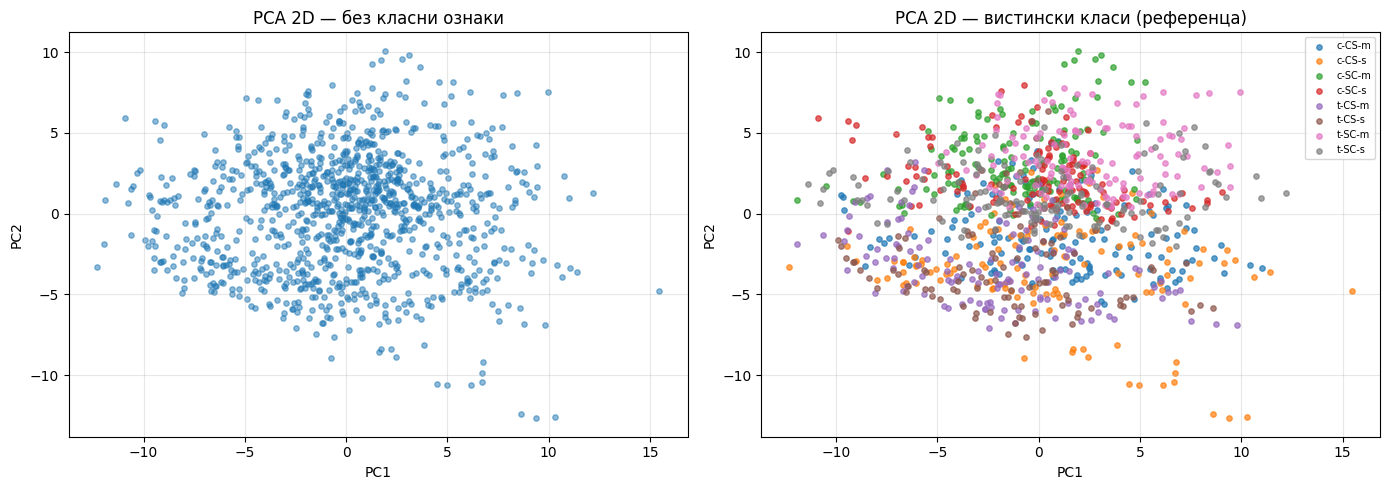

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f'PC1 + PC2 објаснуваат: {sum(pca.explained_variance_ratio_)*100:.1f}% варијанса')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], s=15, alpha=0.5)
ax1.set_title('PCA 2D — без класни ознаки')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.grid(alpha=0.3)

for cls in np.unique(true_labels):
    m = true_labels == cls
    ax2.scatter(X_pca[m, 0], X_pca[m, 1], label=cls, s=15, alpha=0.7)
ax2.set_title('PCA 2D — вистински класи (референца)')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. K-Means Кластерирање

K-Means е итеративен алгоритам:
- **E-чекор:** секоја точка се доделува на најблискиот центроид (hard assignment)
- **M-чекор:** центроидите се ажурираат како просек на точките во кластерот

За избор на K користиме **Elbow метод** и **Silhouette Score**.

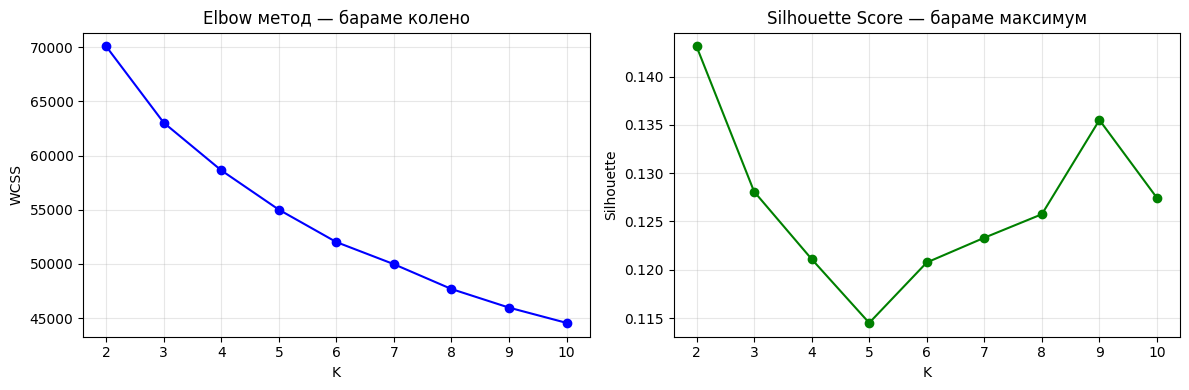

Оптимален K според Silhouette: 2


In [6]:
wcss = []
sil  = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, wcss, 'b-o')
ax1.set_title('Elbow метод — бараме колено')
ax1.set_xlabel('K'); ax1.set_ylabel('WCSS'); ax1.grid(alpha=0.3)

ax2.plot(K_range, sil, 'g-o')
ax2.set_title('Silhouette Score — бараме максимум')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette'); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Оптимален K според Silhouette: {list(K_range)[np.argmax(sil)]}')

In [7]:
# Избираме K=8 врз основа на domain знаење — датасетот има 8 биолошки класи.
K = 8

km = KMeans(n_clusters=K, init='k-means++', n_init=20, random_state=42)
km_labels = km.fit_predict(X)

print('Дистрибуција на кластери:')
unique, counts = np.unique(km_labels, return_counts=True)
for k, c in zip(unique, counts):
    print(f'  Кластер {k}: {c} точки')

km_sil = round(silhouette_score(X, km_labels), 4)
km_ari = round(adjusted_rand_score(true_labels, km_labels), 4)
print(f'\nSilhouette Score: {km_sil}')
print(f'Adjusted Rand Index: {km_ari}')

Дистрибуција на кластери:
  Кластер 0: 144 точки
  Кластер 1: 172 точки
  Кластер 2: 157 точки
  Кластер 3: 136 точки
  Кластер 4: 204 точки
  Кластер 5: 15 точки
  Кластер 6: 157 точки
  Кластер 7: 95 точки

Silhouette Score: 0.1257
Adjusted Rand Index: 0.1284


## 6. DBSCAN Кластерирање

DBSCAN наоѓа кластери врз основа на густина. Параметри:
- **ε (eps):** радиус на пребарување
- **MinPts:** минимален број соседи за core point

**Зошто не директно на 77D?** Curse of dimensionality — во висока димензија сите точки изгледаат подеднакво далеку и eps нема смисла. Затоа прво тестираме со различни PCA димензии.

In [8]:
# Тест со различни PCA димензии — наоѓаме оптимална димензионалност за DBSCAN
print(f'{"PCA":>8} | {"Варијанса":>10} | {"Кластери":>8} | {"Noise":>6} | {"Silhouette":>10} | {"ARI":>8}')
print('-' * 65)

best_results = {}
for n_comp in [2, 5, 10, 15, 20, 25, 30]:
    X_test = PCA(n_components=n_comp, random_state=42).fit_transform(X)
    var = sum(PCA(n_components=n_comp, random_state=42).fit(X).explained_variance_ratio_) * 100

    best_cl, best_eps, best_min, best_no = 0, 0, 0, 0
    best_sil, best_ari = -1, -1

    for eps in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]:
        for min_s in [3, 5, 10]:
            lbls = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_test)
            n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
            n_no = (lbls == -1).sum()
            if 6 <= n_cl <= 10 and n_no < 150:
                mask = lbls != -1
                sil = round(silhouette_score(X_test[mask], lbls[mask]), 4)
                ari = round(adjusted_rand_score(true_labels[mask], lbls[mask]), 4)
                if sil > best_sil:
                    best_cl, best_eps, best_min = n_cl, eps, min_s
                    best_no, best_sil, best_ari = n_no, sil, ari

    if best_cl > 0:
        best_results[n_comp] = {'eps': best_eps, 'min_s': best_min, 'sil': best_sil, 'ari': best_ari, 'cl': best_cl, 'no': best_no}
        print(f'PCA {n_comp:2d}D | {var:>8.1f}% | {best_cl:>8} | {best_no:>6} | {best_sil:>10.4f} | {best_ari:>8.4f}')
    else:
        print(f'PCA {n_comp:2d}D | {var:>8.1f}% | {"нема":>8} | {"":>6} | {"":>10} | {"":>8}')

     PCA |  Варијанса | Кластери |  Noise | Silhouette |      ARI
-----------------------------------------------------------------
PCA  2D |     42.3% |        7 |     20 |    -0.0160 |   0.0001
PCA  5D |     65.3% |     нема |        |            |         
PCA 10D |     80.6% |       10 |     53 |    -0.0675 |   0.0090
PCA 15D |     86.6% |        6 |     25 |     0.0461 |   0.0023
PCA 20D |     90.2% |        9 |     40 |    -0.0202 |   0.0070
PCA 25D |     92.9% |        8 |      7 |     0.0630 |   0.0014
PCA 30D |     94.8% |        8 |      9 |     0.0647 |   0.0015


In [9]:
# Најдобра димензионалност е PCA 25D — највисок Silhouette (0.063), 8 кластери, само 7 noise
BEST_N_COMP = 25
EPS   = best_results[BEST_N_COMP]['eps']
MIN_S = best_results[BEST_N_COMP]['min_s']

X_db = PCA(n_components=BEST_N_COMP, random_state=42).fit_transform(X)
db_labels = DBSCAN(eps=EPS, min_samples=MIN_S).fit_predict(X_db)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
n_core     = len(DBSCAN(eps=EPS, min_samples=MIN_S).fit(X_db).core_sample_indices_)

print(f'PCA димензии: {BEST_N_COMP} | eps={EPS} | minPts={MIN_S}')
print(f'Кластери: {n_clusters} | Core: {n_core} | Noise: {n_noise}')

mask = db_labels != -1
db_sil = round(silhouette_score(X_db[mask], db_labels[mask]), 4)
db_ari = round(adjusted_rand_score(true_labels[mask], db_labels[mask]), 4)
print(f'Silhouette Score: {db_sil}')
print(f'Adjusted Rand Index: {db_ari}')

PCA димензии: 25 | eps=6.0 | minPts=3
Кластери: 8 | Core: 1068 | Noise: 7
Silhouette Score: 0.063
Adjusted Rand Index: 0.0014


## 7. Визуелизација на резултатите

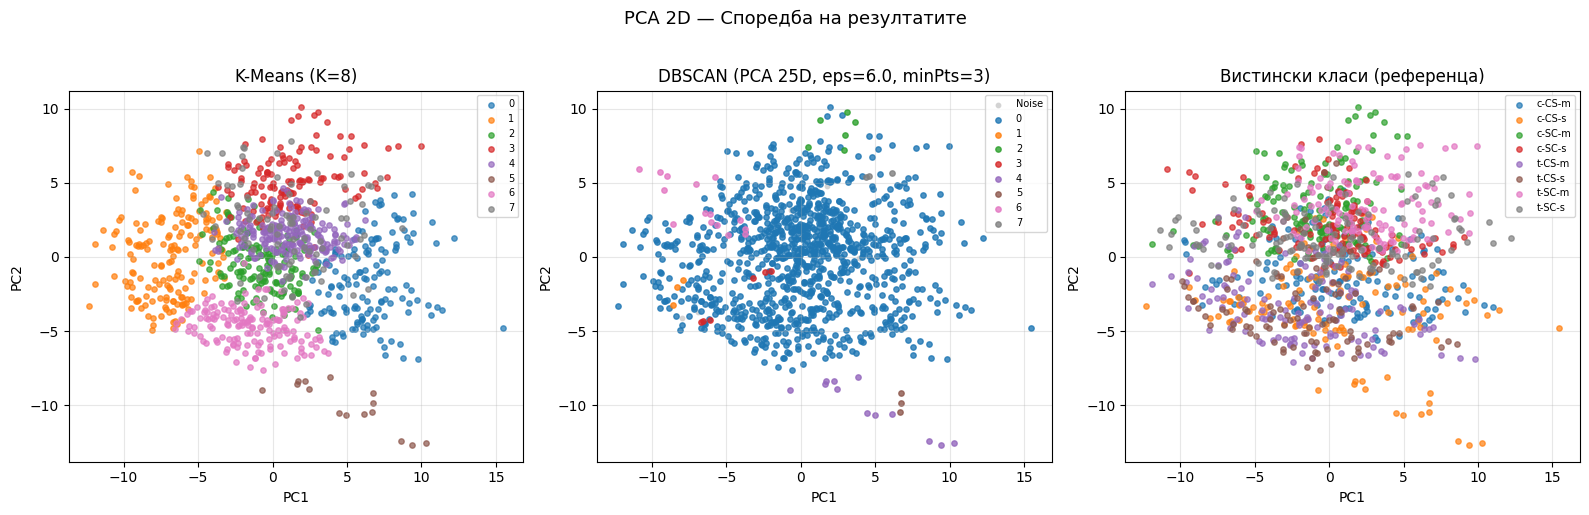

In [10]:
# PCA 2D визуелизација
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k in range(K):
    m = km_labels == k
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=15, alpha=0.7, label=str(k))
axes[0].set_title(f'K-Means (K={K})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].scatter(X_pca[db_labels==-1, 0], X_pca[db_labels==-1, 1],
                c='lightgray', s=10, label='Noise')
for k in range(n_clusters):
    m = db_labels == k
    axes[1].scatter(X_pca[m, 0], X_pca[m, 1], s=15, alpha=0.8, label=str(k))
axes[1].set_title(f'DBSCAN (PCA {BEST_N_COMP}D, eps={EPS}, minPts={MIN_S})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

for cls in np.unique(true_labels):
    m = true_labels == cls
    axes[2].scatter(X_pca[m, 0], X_pca[m, 1], s=15, alpha=0.7, label=cls)
axes[2].set_title('Вистински класи (референца)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

plt.suptitle('PCA 2D — Споредба на резултатите', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Пресметување t-SNE...
Готово!


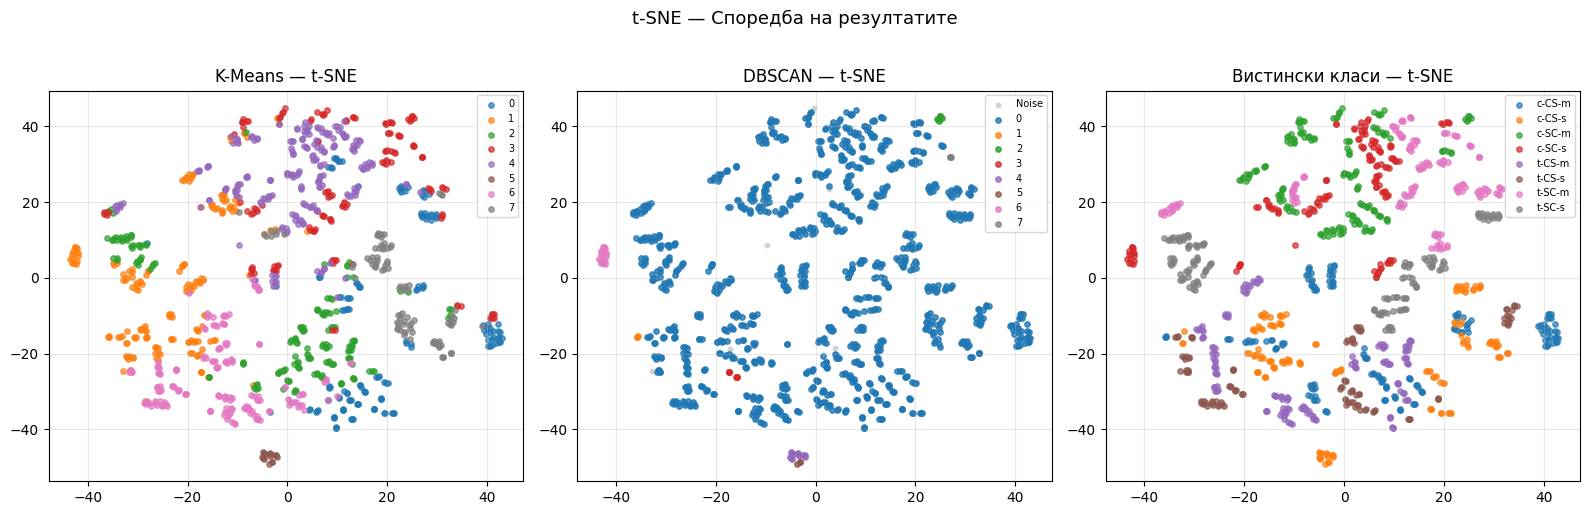

In [11]:
# t-SNE визуелизација
print('Пресметување t-SNE...')
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
print('Готово!')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for k in range(K):
    m = km_labels == k
    axes[0].scatter(X_tsne[m, 0], X_tsne[m, 1], s=15, alpha=0.7, label=str(k))
axes[0].set_title('K-Means — t-SNE')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].scatter(X_tsne[db_labels==-1, 0], X_tsne[db_labels==-1, 1],
                c='lightgray', s=10, label='Noise')
for k in range(n_clusters):
    m = db_labels == k
    axes[1].scatter(X_tsne[m, 0], X_tsne[m, 1], s=15, alpha=0.8, label=str(k))
axes[1].set_title('DBSCAN — t-SNE')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

for cls in np.unique(true_labels):
    m = true_labels == cls
    axes[2].scatter(X_tsne[m, 0], X_tsne[m, 1], s=15, alpha=0.7, label=cls)
axes[2].set_title('Вистински класи — t-SNE')
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

plt.suptitle('t-SNE — Споредба на резултатите', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Заклучок

### Споредба на резултатите

| Метрика | K-Means | DBSCAN |
|---|---|---|
| Silhouette Score | 0.1257 | 0.063 |
| Adjusted Rand Index | 0.1284 | 0.0014 |
| Број на кластери | 8 | 8 |
| PCA димензии | 77D (целосно) | 25D (92.9% варијанса) |

### K-Means
K-Means со K=8 покажа подобри резултати. Elbow и Silhouette не покажаа јасен оптимум, затоа K=8 беше избран врз основа на домејн знаење (датасетот има 8 биолошки класи). ARI=0.13 е разумен резултат за целосно ненадгледувано учење.

### DBSCAN
DBSCAN беше тестиран на PCA простор со 2 до 30 димензии. Најдобри резултати дадоа PCA 25D и 30D (8 кластери, минимален noise, Silhouette≈0.063). Сепак, ARI останува близу 0 без разлика на димензионалноста.

Причини зошто DBSCAN не работи добро:
1. Податоците немаат јасна density структура — класите се рамномерно распоредени
2. Биолошките класи имаат преклопувачки протеински профили
3. DBSCAN е погоден за кластери со произволна форма и јасни густи региони — карактеристики кои овој датасет ги нема

### Општ заклучок
K-Means е значително подобар за овој датасет. И двата алгоритма покажуваат ниски метрики бидејќи ненадгледуваното учење без класни ознаки е тежок проблем — ARI=0.13 за K-Means е разумен резултат.